# Solar capture rate & negative-price hours

The **capture rate** is what a MWh of solar actually earned versus the
plain baseload price. Below 1.00 the technology produces in the hours it
makes cheap — cannibalisation, in the market's own numbers. The PPA/asset
question in one metric.

*Data: ENTSO-E Transparency Platform; Fraunhofer Energy-Charts CC BY 4.0; GIE — via [obsyd.dev](https://obsyd.dev) (free, AGPL-3.0). Descriptive, not a forecast.*

In [1]:
# pip install obsyd matplotlib
import datetime as dt
import matplotlib.pyplot as plt
from obsyd import Obsyd

ob = Obsyd()
# Ranges end YESTERDAY (UTC) — today's late hours may not be published yet.
END = dt.date.today() - dt.timedelta(days=1)
START = END - dt.timedelta(days=90)
ZONE = 'DE_LU'

In [2]:
price = ob.series('price.dayahead', ZONE, start=START, end=END)['value']
solar = ob.series('gen.B16', ZONE, start=START, end=END)['value']
df = price.to_frame('price').join(solar.rename('solar_mw'), how='inner')
len(df)

2160

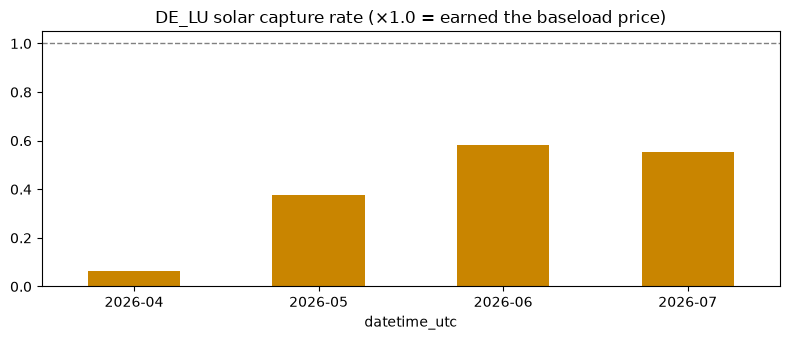

In [3]:
monthly = df.resample('MS').apply(
    lambda m: ((m['price'] * m['solar_mw']).sum() / m['solar_mw'].sum())
              / m['price'].mean() if m['solar_mw'].sum() else None)
monthly.index = monthly.index.strftime('%Y-%m')
ax = monthly.plot(kind='bar', figsize=(8, 3.5), color='#c98500', rot=0)
ax.axhline(1.0, color='gray', ls='--', lw=1)
ax.set_title(f'{ZONE} solar capture rate (×1.0 = earned the baseload price)')
plt.tight_layout()

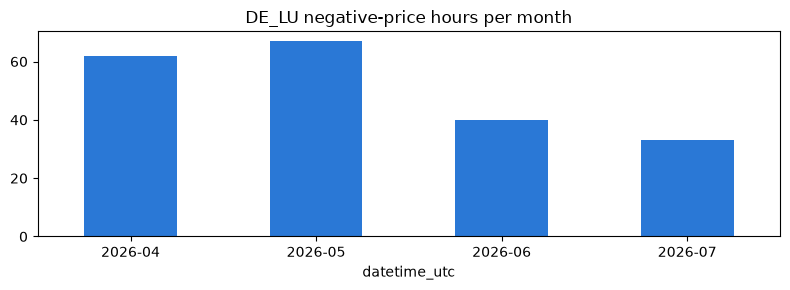

In [4]:
neg = (df['price'] < 0).resample('MS').sum()
neg.index = neg.index.strftime('%Y-%m')
ax = neg.plot(kind='bar', figsize=(8, 3), color='#2a78d6', rot=0)
ax.set_title(f'{ZONE} negative-price hours per month')
plt.tight_layout()